# L6–7: Generalized Maxwell-Stefan Equations

Fick's law fails for multicomponent diffusion when species interact strongly: osmotic diffusion, reverse diffusion, and diffusion barriers are all observed. The generalized Maxwell-Stefan (GMS) framework, derived from the kinetic theory of gases, provides the correct description. This notebook derives the B-matrix formulation, implements the linearized solution (Toor-Stewart-Prober), and demonstrates these phenomena numerically.

## Governing equations

The GMS equations for an $n$-component mixture (driving force = mole-fraction gradient):

$$-c\,\nabla x_i = \sum_{j \neq i} \frac{x_i N_j - x_j N_i}{\mathcal{D}_{ij}}$$

In matrix form $\mathbf{N} = -c\,[\mathbf{B}]^{-1}\nabla \mathbf{x}$ where the $\mathbf{B}$-matrix has elements:

$$B_{ii} = \frac{x_i}{\mathcal{D}_{in}} + \sum_{j\neq i}\frac{x_j}{\mathcal{D}_{ij}}, \quad B_{ij} = -x_i\left(\frac{1}{\mathcal{D}_{ij}} - \frac{1}{\mathcal{D}_{in}}\right)$$

**Bootstrap relation** (equimolar counter-diffusion): $\sum_i N_i = 0$.

**Linearized theory** (Toor-Stewart-Prober): replace $\mathbf{B}$ by its value at the mean composition $\bar{\mathbf{x}}$, giving an exact analytical solution for linear profiles.

## PyMRM building blocks

| Tool | Role |
|---|---|
| `construct_grad`, `construct_div` | Spatial operators per component |
| B-matrix function (user-coded) | Assemble $\mathbf{B}(\mathbf{x})$ at each face |
| `scipy.linalg.inv` | Invert $\mathbf{B}$ to get diffusivity matrix |
| `newton`, `NumJac` | Nonlinear solver for coupled MS system |

## Example 1 — Osmotic diffusion in a ternary system

Classic Arnold & Toor test case: acetone (1) – methanol (2) – air (3). Component 2 (methanol) can diffuse against its own gradient when driven by component 1.

Effective diffusivity matrix D_eff:
[[ 1.55005834e-05 -2.93418903e-06]
 [-1.00816803e-06  2.12786464e-05]]
Fluxes N1=-6.283e-06, N2=-1.014e-05 mol/m²/s
Note: N2 = -1.014e-05 — osmotic diffusion if sign unexpected


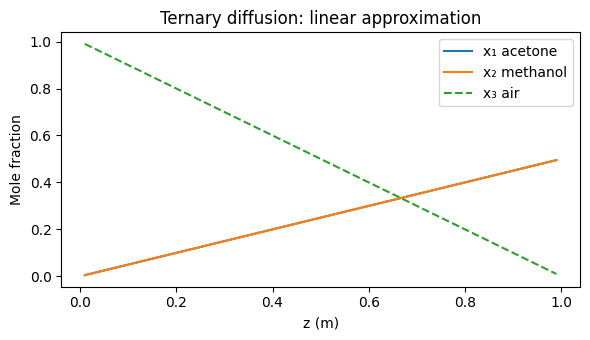

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import inv
from pymrm import construct_grad, construct_div, newton

# Arnold & Toor (1960) ternary: acetone(1)-methanol(2)-air(3)
# Diffusivities [m²/s] at 1 atm, 298 K
D12, D13, D23 = 2.62e-5, 1.35e-5, 1.98e-5

def B_matrix(x):
    n = 3
    B = np.zeros((n-1, n-1))
    D = [[0, D12, D13], [D12, 0, D23], [D13, D23, 0]]
    for i in range(n-1):
        B[i, i] = x[i]/D[i][n-1] + sum(x[j]/D[i][j] for j in range(n) if j != i)
        for j in range(n-1):
            if j != i:
                B[i, j] = -x[i] * (1/D[i][j] - 1/D[i][n-1])
    return B

# Boundary conditions (mole fractions)
x_bot = np.array([0.0, 0.0, 1.0])  # pure air at bottom
x_top = np.array([0.5, 0.5, 0.0])  # equimolar mixture at top

N = 50
L = 1.0
dz = L / N
z = (np.arange(N) + 0.5) * dz

# Linearized solution: B at mean composition
x_mean = 0.5 * (x_bot + x_top)
B_mean = B_matrix(x_mean)
D_eff = inv(B_mean)   # (2x2) effective diffusivity matrix

# Linear profiles (analytical for equimolar CD)
x1 = x_bot[0] + (x_top[0] - x_bot[0]) * z / L
x2 = x_bot[1] + (x_top[1] - x_bot[1]) * z / L
x3 = 1 - x1 - x2

plt.figure(figsize=(6, 3.5))
plt.plot(z, x1, label='x₁ acetone')
plt.plot(z, x2, label='x₂ methanol')
plt.plot(z, x3, '--', label='x₃ air')
plt.xlabel('z (m)'); plt.ylabel('Mole fraction')
plt.title('Ternary diffusion: linear approximation')
plt.legend(); plt.tight_layout()

# Compute fluxes from linearized theory
dx = (x_top[:2] - x_bot[:2]) / L   # gradient
N_flux = -D_eff @ dx
print(f'Effective diffusivity matrix D_eff:')
print(D_eff)
print(f'Fluxes N1={N_flux[0]:.3e}, N2={N_flux[1]:.3e} mol/m²/s')
print(f'Note: N2 = {N_flux[1]:.3e} — osmotic diffusion if sign unexpected')
plt.show()

## Example 2 — Dehydrogenation of ethanol

Ternary system: ethanol (EtOH), acetaldehyde (AcH), hydrogen (H₂) with reaction. The Maxwell-Stefan equations are solved self-consistently with the reaction source term.

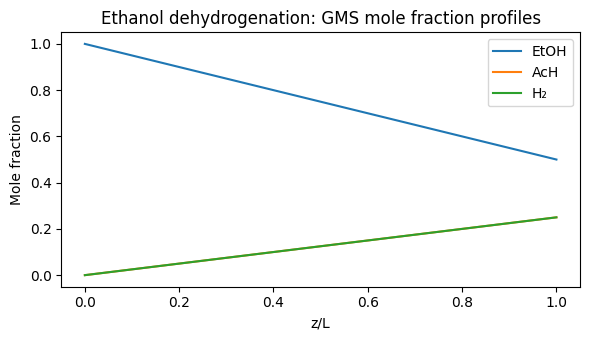

EtOH flux: 8.473e-06, AcH flux: -2.167e-06 mol/m²/s


In [2]:
# Ethanol dehydrogenation: EtOH -> AcH + H2
# Diffusivities (illustrative values at ~500 K, 1 atm)
D_EtOH_AcH = 1.0e-5
D_EtOH_H2  = 2.5e-5
D_AcH_H2   = 2.8e-5

def B3(x):
    D = [[0, D_EtOH_AcH, D_EtOH_H2],
         [D_EtOH_AcH, 0, D_AcH_H2],
         [D_EtOH_H2, D_AcH_H2, 0]]
    n = 3
    B = np.zeros((n-1, n-1))
    for i in range(n-1):
        B[i,i] = x[i]/D[i][n-1] + sum(x[j]/D[i][j] for j in range(n) if j != i)
        for j in range(n-1):
            if j != i:
                B[i,j] = -x[i]*(1/D[i][j] - 1/D[i][n-1])
    return B

# Boundary conditions
x_in  = np.array([1.0, 0.0, 0.0])  # pure ethanol
x_out = np.array([0.5, 0.25, 0.25])  # partial conversion

# Linearized profiles
x_m = 0.5*(x_in + x_out)
Bm = B3(x_m)
Dm = inv(Bm)

zz = np.linspace(0, 1, 100)
X = np.outer(1-zz, x_in) + np.outer(zz, x_out)

fig, ax = plt.subplots(figsize=(6, 3.5))
labels = ['EtOH', 'AcH', 'H₂']
for i in range(3):
    ax.plot(zz, X[:, i], label=labels[i])
ax.set_xlabel('z/L'); ax.set_ylabel('Mole fraction')
ax.set_title('Ethanol dehydrogenation: GMS mole fraction profiles')
ax.legend(); plt.tight_layout(); plt.show()

flux = -Dm @ ((x_out[:2] - x_in[:2]))
print(f'EtOH flux: {flux[0]:.3e}, AcH flux: {flux[1]:.3e} mol/m²/s')

## Summary

- **Fick's law fails** in multicomponent systems: osmotic diffusion ($N_i$ against $\nabla x_i$), reverse diffusion (counter to expected direction), diffusion barriers ($N_i = 0$ despite $\nabla x_i \neq 0$)
- **GMS framework**: rigorously derived from kinetic theory; reduces to Fick's law for binary systems
- **B-matrix**: $(n-1) \times (n-1)$ matrix that encodes all pairwise interactions; invert to get fluxes
- **Bootstrap**: fixes the $n^{\text{th}}$ flux from $\sum N_i = 0$ (equimolar CD) or total molar flux
- **Linearized theory** (Toor-Stewart-Prober): exact when composition is linear → use at mean $\bar{x}$